# CERN CMS Dielectron  Notebook 3: Sensor Cost vs Accuracy Tradeoff

Measures how prediction accuracy changes as sensors are added progressively (greedy forward selection). Compares Linear Regression vs MLP to find the minimal sensor set for near-peak accuracy.

In [ ]:
#importing libraries and setup
!pip install -q kagglehub shap
try:
    import torch
except ImportError:
    !pip install -q torch

import kagglehub, os
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
import warnings; warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.decomposition import PCA
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score,
                             classification_report, confusion_matrix,
                             accuracy_score, f1_score)

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams.update({'figure.figsize':(12,5), 'font.size':12})
np.random.seed(42)
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Running on: {DEVICE}')

Running on: cuda


Loading Data

In [ ]:
path = kagglehub.dataset_download('fedesoriano/cern-electron-collision-data')
df = pd.read_csv(os.path.join(path, 'dielectron.csv'))
df.columns = df.columns.str.strip()  # fix trailing spaces
print(f'Shape: {df.shape}')
df.head()

#clean data
df = df.dropna(subset=['M']).drop_duplicates().reset_index(drop=True)

#Drop Run and Event (run/event IDs have no predictive value)
df = df.drop(columns=['Run', 'Event'], errors='ignore')

Using Colab cache for faster access to the 'cern-electron-collision-data' dataset.
Shape: (100000, 19)


Feature Engineering

In [ ]:
#Feature Engineering

#Physics-motivated features
df['delta_eta'] = df['eta1'] - df['eta2']
df['delta_phi'] = df['phi1'] - df['phi2']
df['delta_R']   = np.sqrt(df['delta_eta']**2 + df['delta_phi']**2)
df['pt_total']  = df['pt1'] + df['pt2']
df['pt_asym']   = (df['pt1'] - df['pt2']) / (df['pt1'] + df['pt2'] + 1e-10)
df['E_total']   = df['E1'] + df['E2']
df['E_ratio']   = df['E1'] / (df['E2'] + 1e-10)
df['Q_sum']     = df['Q1'] + df['Q2']
df['cos_theta_star'] = np.tanh(df['delta_eta'] / 2)

print(f'After cleaning: {df.shape}')
print(f'Features created: delta_eta, delta_phi, delta_R, pt_total, pt_asym, E_total, E_ratio, Q_sum, cos_theta_star')

After cleaning: (99892, 26)
Features created: delta_eta, delta_phi, delta_R, pt_total, pt_asym, E_total, E_ratio, Q_sum, cos_theta_star


Defining classes

In [ ]:
#Define M bins for classification evaluation
def mass_to_class(m):
    if m < 6:
        return 'J/psi_region'
    elif m < 15:
        return 'Upsilon_region'
    elif m < 70:
        return 'Continuum'
    else:
        return 'Z_boson'

df['label'] = df['M'].apply(mass_to_class)
print('\nClass distribution:')
print(df['label'].value_counts().sort_index())

le = LabelEncoder()
df['label_enc'] = le.fit_transform(df['label'])
print(f'\nClasses: {list(le.classes_)}')


Class distribution:
label
Continuum         55993
J/psi_region       9847
Upsilon_region    22910
Z_boson           11142
Name: count, dtype: int64

Classes: ['Continuum', 'J/psi_region', 'Upsilon_region', 'Z_boson']


Defining features and target

In [ ]:
# All sensor/physical property columns (everything except M and derived labels)
feature_cols = [c for c in df.columns if c not in ['M', 'label', 'label_enc']]
print(f'Feature columns ({len(feature_cols)}): {feature_cols}')

X = df[feature_cols].values
y_reg = df['M'].values          # Regression target: continuous M
y_cls = df['label_enc'].values   # Classification target: binned M

Feature columns (25): ['E1', 'px1', 'py1', 'pz1', 'pt1', 'eta1', 'phi1', 'Q1', 'E2', 'px2', 'py2', 'pz2', 'pt2', 'eta2', 'phi2', 'Q2', 'delta_eta', 'delta_phi', 'delta_R', 'pt_total', 'pt_asym', 'E_total', 'E_ratio', 'Q_sum', 'cos_theta_star']


In [ ]:
#Train/Test Split
X_train, X_test, y_train_reg, y_test_reg, y_train_cls, y_test_cls = train_test_split(
    X, y_reg, y_cls, test_size=0.2, random_state=42
)

In [ ]:
#Standardise
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'\nTrain: {X_train_s.shape}, Test: {X_test_s.shape}')


Train: (79913, 25), Test: (19979, 25)


**GPU accelerated MLP Regressor**

In [ ]:
class TorchMLPRegressor:
    def __init__(self, hidden_layer_sizes=(256, 128, 64), activation='relu',
                 lr=5e-4, max_iter=500, batch_size=512,
                 early_stopping=True, patience=20, random_state=42):
        self.hidden_layer_sizes = hidden_layer_sizes
        self.activation = activation
        self.lr = lr
        self.max_iter = max_iter
        self.batch_size = batch_size
        self.early_stopping = early_stopping
        self.patience = patience
        self.random_state = random_state
        self.device = DEVICE
        self.net = None
        self.loss_curve_ = []

    def _build_net(self, n_features):
        act_fn = nn.ReLU() if self.activation == 'relu' else nn.Tanh()
        layers, in_dim = [], n_features
        for h in self.hidden_layer_sizes:
            layers += [
                nn.Linear(in_dim, h),
                act_fn,
                nn.BatchNorm1d(h),
                nn.Dropout(0.2),
            ]
            in_dim = h
        layers.append(nn.Linear(in_dim, 1))  # Single output for regression
        return nn.Sequential(*layers).to(self.device)

    def fit(self, X, y):
        if self.random_state is not None:
            torch.manual_seed(self.random_state)
            if self.device.type == 'cuda':
                torch.cuda.manual_seed_all(self.random_state)

        self.net = self._build_net(X.shape[1])
        optimiser = torch.optim.Adam(self.net.parameters(), lr=self.lr)
        criterion = nn.MSELoss()

        X_t = torch.tensor(X, dtype=torch.float32)
        y_t = torch.tensor(y, dtype=torch.float32).unsqueeze(1)

        if self.early_stopping:
            n_val = max(int(0.1 * len(X_t)), 1)
            X_tr, X_val = X_t[:-n_val], X_t[-n_val:]
            y_tr, y_val = y_t[:-n_val], y_t[-n_val:]
        else:
            X_tr, y_tr = X_t, y_t
            X_val, y_val = None, None

        loader = DataLoader(
            TensorDataset(X_tr, y_tr),
            batch_size=self.batch_size, shuffle=True
        )

        best_val_loss = float('inf')
        patience_count = 0
        self.loss_curve_ = []

        for epoch in range(self.max_iter):
            self.net.train()
            epoch_loss = 0.0
            for Xb, yb in loader:
                Xb, yb = Xb.to(self.device), yb.to(self.device)
                optimiser.zero_grad()
                loss = criterion(self.net(Xb), yb)
                loss.backward()
                optimiser.step()
                epoch_loss += loss.item() * len(Xb)
            epoch_loss /= len(X_tr)
            self.loss_curve_.append(epoch_loss)

            if self.early_stopping:
                self.net.eval()
                with torch.no_grad():
                    val_loss = criterion(
                        self.net(X_val.to(self.device)),
                        y_val.to(self.device)
                    ).item()
                if val_loss < best_val_loss - 1e-4:
                    best_val_loss = val_loss
                    patience_count = 0
                else:
                    patience_count += 1
                    if patience_count >= self.patience:
                        print(f'  [TorchMLP] Early stop at epoch {epoch+1}')
                        break
        return self

    def predict(self, X):
        self.net.eval()
        with torch.no_grad():
            preds = self.net(
                torch.tensor(X, dtype=torch.float32).to(self.device)
            )
            return preds.squeeze().cpu().numpy()

print(f'TorchMLPRegressor will train on: {DEVICE}')

TorchMLPRegressor will train on: cuda


## Sensor Cost vs Accuracy Tradeoff

Each physical property measurement requires a sensor, and sensors have costs.  
We systematically evaluate how accuracy changes as we use fewer sensors.

**Approach**: Use PCA to rank features by variance contribution, then progressively add features and measure regression R².

Group features by their "sensor" (what they measure)

In [ ]:
sensor_groups = {
    'Energy (E1, E2)':         ['E1', 'E2'],
    'Momentum-x (px1, px2)':   ['px1', 'px2'],
    'Momentum-y (py1, py2)':   ['py1', 'py2'],
    'Momentum-z (pz1, pz2)':   ['pz1', 'pz2'],
    'Transverse-p (pt1, pt2)': ['pt1', 'pt2'],
    'Pseudorapidity (η1, η2)': ['eta1', 'eta2'],
    'Azimuthal (φ1, φ2)':      ['phi1', 'phi2'],
    'Charge (Q1, Q2)':         ['Q1', 'Q2'],
    'Derived features':        ['delta_eta', 'delta_phi', 'delta_R', 'pt_total',
                                'pt_asym', 'E_total', 'E_ratio', 'Q_sum', 'cos_theta_star'],
}

Evaluate each sensor group individually

In [ ]:
sensor_individual_results = {}
for group_name, cols in sensor_groups.items():
    valid_cols = [c for c in cols if c in feature_cols]
    if not valid_cols:
        continue
    col_idx = [feature_cols.index(c) for c in valid_cols]
    X_tr = X_train_s[:, col_idx]
    X_te = X_test_s[:, col_idx]

    lr_temp = LinearRegression()
    lr_temp.fit(X_tr, y_train_reg)
    y_pred = lr_temp.predict(X_te)
    r2 = r2_score(y_test_reg, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred))
    sensor_individual_results[group_name] = {'r2': r2, 'rmse': rmse, 'n_sensors': len(valid_cols)}

In [ ]:
#Display
print('Individual Sensor Group Performance (Linear Regression)')
print(f'{"Sensor Group":40s} | {"R²":>8s} | {"RMSE":>8s} | {"# Sensors":>9s}')
print('-' * 75)
for name, res in sorted(sensor_individual_results.items(), key=lambda x: -x[1]['r2']):
    print(f'{name:40s} | {res["r2"]:8.4f} | {res["rmse"]:8.4f} | {res["n_sensors"]:>9d}')

Individual Sensor Group Performance (Linear Regression)
Sensor Group                             |       R² |     RMSE | # Sensors
---------------------------------------------------------------------------
Derived features                         |   0.6620 |  14.6783 |         9
Transverse-p (pt1, pt2)                  |   0.3917 |  19.6913 |         2
Energy (E1, E2)                          |   0.2147 |  22.3735 |         2
Pseudorapidity (η1, η2)                  |   0.0001 |  25.2453 |         2
Momentum-z (pz1, pz2)                    |   0.0001 |  25.2455 |         2
Momentum-y (py1, py2)                    |   0.0001 |  25.2456 |         2
Momentum-x (px1, px2)                    |   0.0000 |  25.2463 |         2
Azimuthal (φ1, φ2)                       |   0.0000 |  25.2465 |         2
Charge (Q1, Q2)                          |   0.0000 |  25.2467 |         2


Progressive addition (greedy forward selection)

In [ ]:
# Start with most important feature group, add one at a time

sorted_groups = sorted(sensor_individual_results.items(), key=lambda x: -x[1]['r2'])
cumulative_features = []
progressive_results = []

for group_name, _ in sorted_groups:
    valid_cols = [c for c in sensor_groups[group_name] if c in feature_cols]
    cumulative_features.extend(valid_cols)

    col_idx = [feature_cols.index(c) for c in cumulative_features]
    X_tr = X_train_s[:, col_idx]
    X_te = X_test_s[:, col_idx]

    lr_temp = LinearRegression()
    lr_temp.fit(X_tr, y_train_reg)
    y_pred = lr_temp.predict(X_te)

    r2 = r2_score(y_test_reg, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred))

    progressive_results.append({
        'group_added': group_name,
        'total_sensors': len(cumulative_features),
        'r2': r2,
        'rmse': rmse
    })

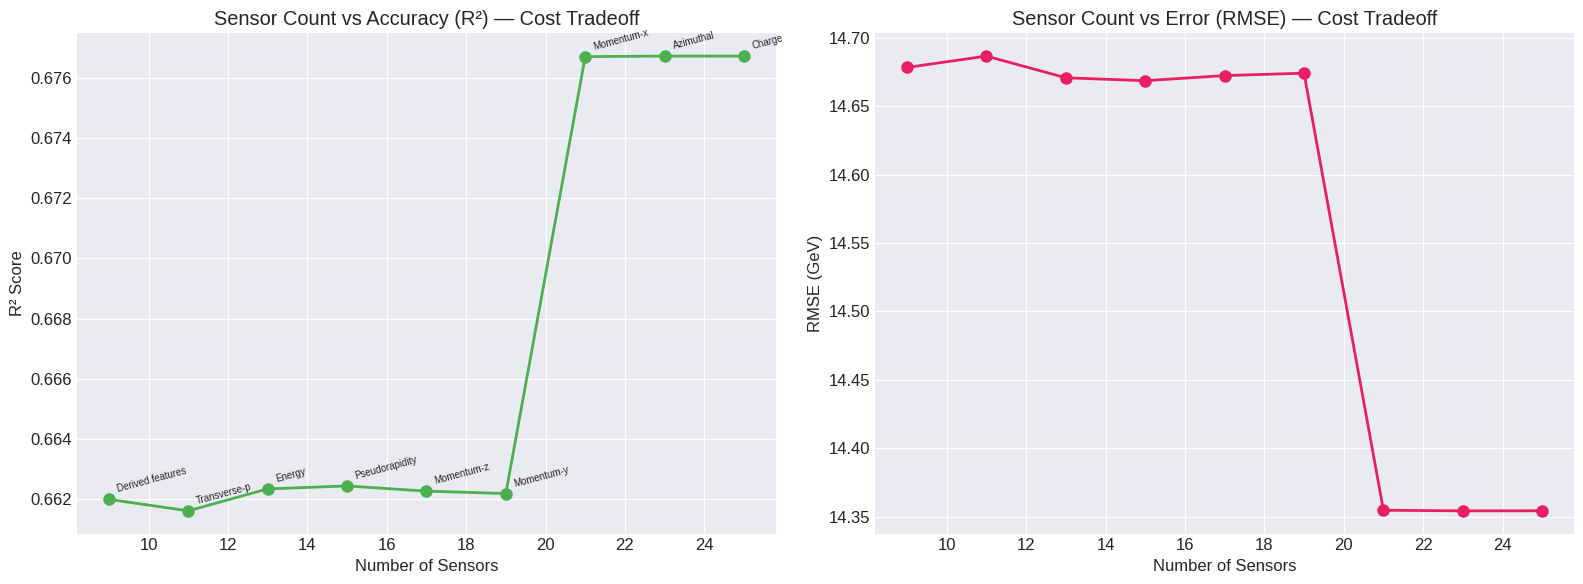

In [ ]:
# Visualise
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

n_sensors = [r['total_sensors'] for r in progressive_results]
r2_scores = [r['r2'] for r in progressive_results]
rmse_scores = [r['rmse'] for r in progressive_results]
groups_added = [r['group_added'] for r in progressive_results]

axes[0].plot(n_sensors, r2_scores, 'o-', color='#4CAF50', lw=2, ms=8)
axes[0].set_xlabel('Number of Sensors')
axes[0].set_ylabel('R² Score')
axes[0].set_title('Sensor Count vs Accuracy (R²) — Cost Tradeoff')
for x, y, g in zip(n_sensors, r2_scores, groups_added):
    axes[0].annotate(g.split('(')[0].strip(), (x, y), fontsize=7,
                     textcoords='offset points', xytext=(5, 5), rotation=15)

axes[1].plot(n_sensors, rmse_scores, 'o-', color='#E91E63', lw=2, ms=8)
axes[1].set_xlabel('Number of Sensors')
axes[1].set_ylabel('RMSE (GeV)')
axes[1].set_title('Sensor Count vs Error (RMSE) — Cost Tradeoff')

plt.tight_layout(); plt.show()

In [ ]:
# Print progressive results
print('\nSensor Cost–Accuracy Tradeoff (Greedy Forward Selection)')
print(f'{"Step":>4s} | {"Group Added":40s} | {"Total Sensors":>13s} | {"R²":>8s} | {"RMSE":>8s}')
print('-' * 85)
for i, r in enumerate(progressive_results):
    print(f'{i+1:4d} | {r["group_added"]:40s} | {r["total_sensors"]:>13d} | {r["r2"]:8.4f} | {r["rmse"]:8.4f}')


Sensor Cost–Accuracy Tradeoff (Greedy Forward Selection)
Step | Group Added                              | Total Sensors |       R² |     RMSE
-------------------------------------------------------------------------------------
   1 | Derived features                         |             9 |   0.6620 |  14.6783
   2 | Transverse-p (pt1, pt2)                  |            11 |   0.6616 |  14.6867
   3 | Energy (E1, E2)                          |            13 |   0.6623 |  14.6708
   4 | Pseudorapidity (η1, η2)                  |            15 |   0.6624 |  14.6687
   5 | Momentum-z (pz1, pz2)                    |            17 |   0.6623 |  14.6724
   6 | Momentum-y (py1, py2)                    |            19 |   0.6622 |  14.6742
   7 | Momentum-x (px1, px2)                    |            21 |   0.6767 |  14.3547
   8 | Azimuthal (φ1, φ2)                       |            23 |   0.6767 |  14.3543
   9 | Charge (Q1, Q2)                          |            25 |   0.6767 |  14.3

### MLP Based Sensor Cost Analysis

The linear regression cost analysis may underestimate accuracy with fewer sensors.
The MLP can exploit non-linear relationships, potentially needing fewer sensors.

In [ ]:
#MLP sensor cost analysis (greedy forward selection)
mlp_progressive_results = []
mlp_cumulative_features = []

for group_name, _ in sorted_groups:
    valid_cols = [c for c in sensor_groups[group_name] if c in feature_cols]
    mlp_cumulative_features.extend(valid_cols)

    col_idx = [feature_cols.index(c) for c in mlp_cumulative_features]
    X_tr = X_train_s[:, col_idx]
    X_te = X_test_s[:, col_idx]

    # Train a quick MLP
    mlp_temp = TorchMLPRegressor(
        hidden_layer_sizes=(128, 64), lr=1e-3, max_iter=200,
        batch_size=512, early_stopping=True, patience=10
    )
    mlp_temp.fit(X_tr, y_train_reg)
    y_pred = mlp_temp.predict(X_te)

    r2 = r2_score(y_test_reg, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred))

    mlp_progressive_results.append({
        'group_added': group_name,
        'total_sensors': len(mlp_cumulative_features),
        'r2': r2, 'rmse': rmse
    })
    print(f"  Added {group_name}: {len(mlp_cumulative_features)} sensors → R²={r2:.4f}")

  [TorchMLP] Early stop at epoch 53
  Added Derived features: 9 sensors → R²=0.9958
  [TorchMLP] Early stop at epoch 39
  Added Transverse-p (pt1, pt2): 11 sensors → R²=0.9961
  [TorchMLP] Early stop at epoch 47
  Added Energy (E1, E2): 13 sensors → R²=0.9958
  [TorchMLP] Early stop at epoch 55
  Added Pseudorapidity (η1, η2): 15 sensors → R²=0.9959
  [TorchMLP] Early stop at epoch 41
  Added Momentum-z (pz1, pz2): 17 sensors → R²=0.9967
  [TorchMLP] Early stop at epoch 47
  Added Momentum-y (py1, py2): 19 sensors → R²=0.9954
  [TorchMLP] Early stop at epoch 58
  Added Momentum-x (px1, px2): 21 sensors → R²=0.9956
  [TorchMLP] Early stop at epoch 43
  Added Azimuthal (φ1, φ2): 23 sensors → R²=0.9946
  [TorchMLP] Early stop at epoch 43
  Added Charge (Q1, Q2): 25 sensors → R²=0.9952


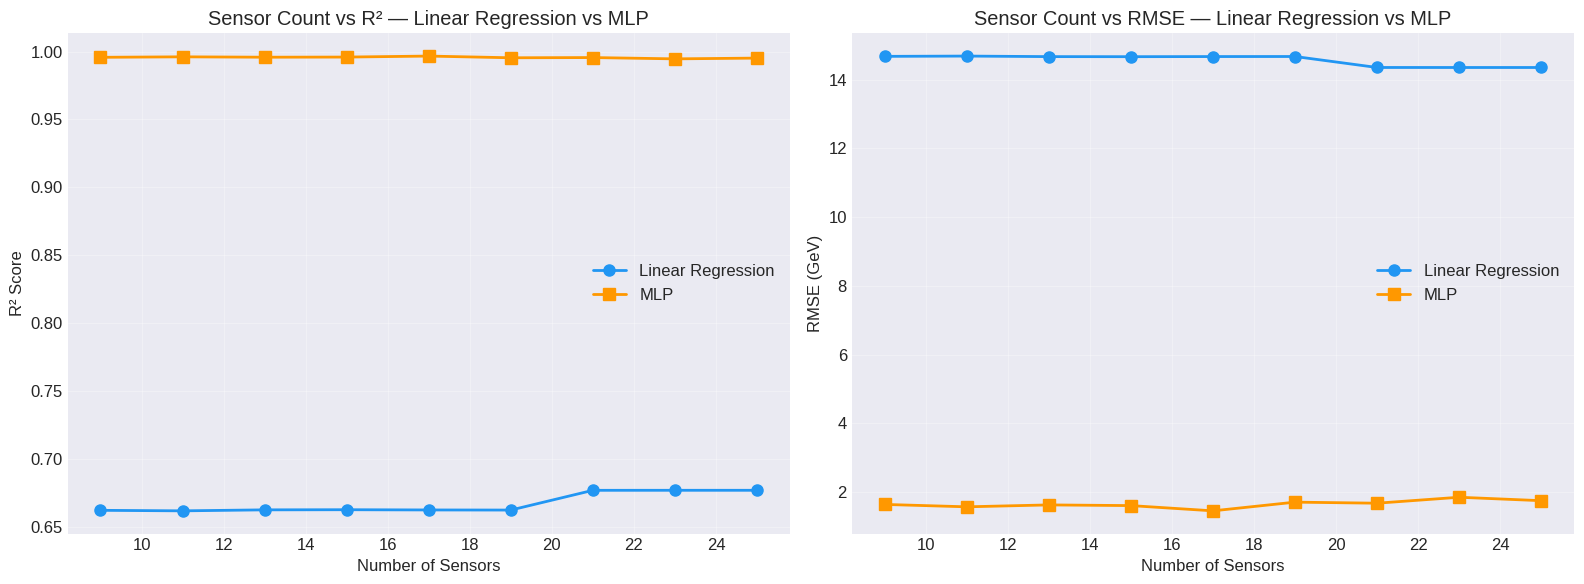

In [ ]:
# Compare LR vs MLP sensor cost
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

n_lr = [r['total_sensors'] for r in progressive_results]
r2_lr = [r['r2'] for r in progressive_results]
n_mlp = [r['total_sensors'] for r in mlp_progressive_results]
r2_mlp = [r['r2'] for r in mlp_progressive_results]

axes[0].plot(n_lr, r2_lr, 'o-', color='#2196F3', lw=2, ms=8, label='Linear Regression')
axes[0].plot(n_mlp, r2_mlp, 's-', color='#FF9800', lw=2, ms=8, label='MLP')
axes[0].set_xlabel('Number of Sensors'); axes[0].set_ylabel('R² Score')
axes[0].set_title('Sensor Count vs R² — Linear Regression vs MLP')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

rmse_lr_p = [r['rmse'] for r in progressive_results]
rmse_mlp_p = [r['rmse'] for r in mlp_progressive_results]
axes[1].plot(n_lr, rmse_lr_p, 'o-', color='#2196F3', lw=2, ms=8, label='Linear Regression')
axes[1].plot(n_mlp, rmse_mlp_p, 's-', color='#FF9800', lw=2, ms=8, label='MLP')
axes[1].set_xlabel('Number of Sensors'); axes[1].set_ylabel('RMSE (GeV)')
axes[1].set_title('Sensor Count vs RMSE — Linear Regression vs MLP')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

### Key Finding :- MLP Sensor Cost

The MLP achieves **R² ≈ 0.996** with only the **9 derived features** alone virtually identical to its performance with all 25 features.

once the angular separations (Δη, Δφ, ΔR), energy sums (E_total), and transverse momentum combinations (pt_total, pt_asym) are computed, the raw momentum components (px, py, pz) add essentially no additional information to the neural network.

In contrast, linear regression plateaus at R² ≈ 0.68 regardless of how many sensors are added, confirming that the invariant mass relationship is fundamentally non-linear and the MLP captures this with a minimal sensor set.

**Practical implication** :- A detector could be designed with just the derived kinematic features and achieve near perfect M prediction, reducing cost without sacrificing accuracy.